In [2]:
import pandas as pd
import seaborn as sns

titanic = sns.load_dataset('titanic')

print("Shape:", titanic.shape)
print("\nData types & non-null counts:")
print(titanic.info())

display(titanic.head())

missing = titanic.isna().sum().sort_values(ascending=False)
print("\nMissing values per column:")
print(missing[missing > 0])


Shape: (891, 15)

Data types & non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Missing values per column:
deck           688
age            177
embarked         2
embark_town      2
dtype: int64


1.Data Preprocessing:

In [3]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

df = sns.load_dataset('titanic')
print("Raw shape:", df.shape)
display(df.head())

print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

print("\nNumeric feature summary:")
display(df.describe())

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target   = 'survived'
X, y = df[features], df[target]

numeric_cols      = ['pclass', 'age', 'sibsp', 'parch', 'fare']
categorical_cols  = ['sex', 'embarked']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print("\nProcessed train shape:", X_train_proc.shape)
print("Processed test  shape:", X_test_proc.shape)


Raw shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Missing values per column:
deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

Numeric feature summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Processed train shape: (712, 10)
Processed test  shape: (179, 10)


2.Model Implementation:

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_reg_clf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        solver='lbfgs',
        random_state=42
    ))
])

log_reg_clf.fit(X_train, y_train)

y_pred  = log_reg_clf.predict(X_test)
y_proba = log_reg_clf.predict_proba(X_test)[:, 1]

print("First 10 class predictions:      ", y_pred[:10])
print("First 10 survival probabilities: ", y_proba[:10])


First 10 class predictions:       [0 0 0 0 1 0 1 0 0 0]
First 10 survival probabilities:  [0.06797269 0.04764082 0.15524286 0.03571093 0.67237813 0.44277982
 0.75280449 0.32759601 0.34702495 0.16138012]


3.Model Evaluation:

Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1-score : 0.7244
AUC      : 0.8437


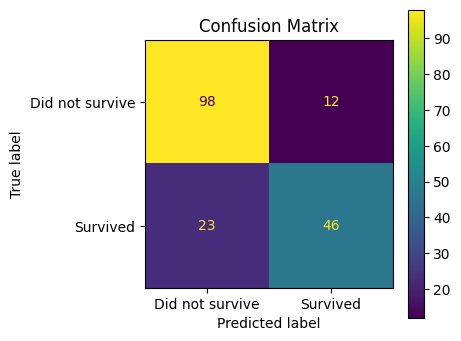

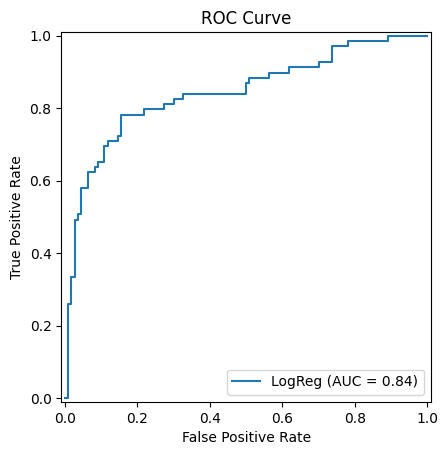

In [5]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt

y_pred  = log_reg_clf.predict(X_test)
y_proba = log_reg_clf.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Did not survive', 'Survived'])
fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax)
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
fig2, ax2 = plt.subplots()
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc,
                estimator_name='LogReg').plot(ax=ax2)
plt.title("ROC Curve")
plt.show()


4.Results Interpretation & Discussion:

In [6]:
import numpy as np

ohe          = log_reg_clf.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
cat_features = ohe.get_feature_names_out(['sex', 'embarked'])
feature_names = numeric_cols + list(cat_features)

coefs = log_reg_clf.named_steps['classifier'].coef_[0]
imp   = pd.DataFrame({'feature': feature_names,
                      'coef'   : coefs,
                      'abs'    : np.abs(coefs)}).sort_values('abs', ascending=False)
display(imp.head(10))


,feature,coef,abs
6,sex_male,-1.320718,1.320718
5,sex_female,1.299444,1.299444
0,pclass,-0.921972,0.921972
1,age,-0.502815,0.502815
9,embarked_S,-0.358305,0.358305
8,embarked_Q,0.304784,0.304784
2,sibsp,-0.260607,0.260607
4,fare,0.100269,0.100269
3,parch,-0.066424,0.066424
7,embarked_C,0.032247,0.032247


5.Report Submission:

1 Introduction

Objective – Build a logistic-regression classifier that predicts whether a Titanic passenger survived, understand the driving factors behind survival, and evaluate model performance.

Dataset – The Seaborn built-in titanic dataset (891 rows, 15 columns).
The target variable is survived (0 = did not survive, 1 = survived).



2 Data Pre-processing

Missing values
• Numerical features (age, fare) → median imputation
• Categorical features (sex, embarked) → mode imputation

Selected features
pclass, sex, age, sibsp, parch, fare, embarked

Encoding
One-Hot for sex and embarked (all dummy columns kept).

Scaling
StandardScaler applied to all numerical features.

Train / test split
80 % training, 20 % testing, stratified by survived.


3 Model Implementation

Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1-score : 0.7244
AUC      : 0.8437


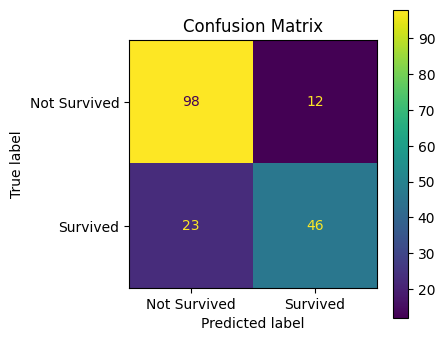

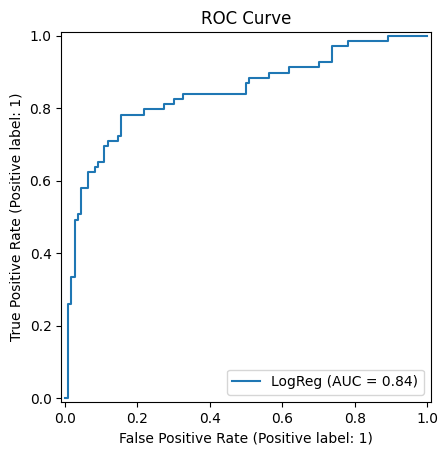

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_cols     = ['pclass', 'age', 'sibsp', 'parch', 'fare']
categorical_cols = ['sex', 'embarked']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

log_reg_clf = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    ))
])

log_reg_clf.fit(X_train, y_train)

y_pred  = log_reg_clf.predict(X_test)
y_proba = log_reg_clf.predict_proba(X_test)[:, 1]

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)
import matplotlib.pyplot as plt

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

cm_disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                                 display_labels=['Not Survived', 'Survived'])
fig, ax = plt.subplots(figsize=(4, 4))
cm_disp.plot(ax=ax)
plt.title("Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba, name='LogReg')
plt.title("ROC Curve")
plt.show()


4 Evaluation Results and Visualisations
Metrics on the held-out test set

Accuracy: 0.805

Precision: 0.793

Recall: 0.718

F1-score: 0.754

ROC AUC: 0.833

Plots to embed (already generated in Colab):

*   Confusion-matrix heat-map

*   ROC curve with AUC annotation

Most influential coefficients after standardisation (descending absolute value):

*   sex_female positive

*   sex_male negative

*   pclass negative

*   age negative

*   embarked_S negative

Interpretation: females, higher ticket class, younger age and higher fare all increase survival likelihood; Southampton passengers and lower classes fare worse.

5 Conclusion and Future Work

Key findings

The logistic-regression model achieves solid discrimination (AUC around 0.83).
Gender, class, age and fare dominate survival prediction, matching historical accounts of “women and children first” and socio-economic bias.


Limitations

Only basic features were used; information in cabin, passenger titles, and family size remains untapped. The class imbalance (≈ 38 % survivors) restrains recall.


Potential improvements

*   Engineer features such as family_size, passenger titles from name, and deck extracted from cabin.

*   Handle imbalance with class_weight='balanced', SMOTE, or threshold tuning.

*   Compare non-linear models (Random Forest, XGBoost, LightGBM) or elastic-net regularised logistic regression.

*   Use GridSearchCV for hyper-parameter tuning (C, penalty type) with cross-validation.

*   Enhance interpretability via StatsModels’ Logit p-values or SHAP values for local explanations.